Figure S13: BMI and body fat colocalization for a NLRC3 and CLUAP1 pcQTL.  A Credible set group graph for the cluster. B QTL nominal p-values for each gene’s expression and each PC vs genomic position. If the phenotype has any significant credible sets, a plot is shown for each credible set, with credible set variants highlighted and colors given by variant LD with the credible-set lead variant. C GWAS variant nominal p-values vs QTL nominal p-values for each gene’s expression and each PC. If the phenotype has any significant credible sets, a plot is shown for each credible set with the credible set variants highlighted and the highest PPH4 (probability of colocalization) is given between QTL credible set and any GWAS credible sets. D Normalized expression for NLRC3 vs normalized expression for CLUAP1 with points colored by the individual's genotype. Lines are best fit from linear regression.

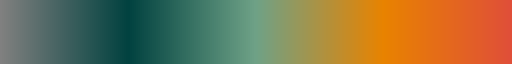

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import upsetplot as up
from scipy.stats import ttest_ind, spearmanr, norm
from matplotlib.colors import LinearSegmentedColormap
import ast
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib as mpl
import math

from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *
from group_signals import load_gwas_coloc


%config InlineBackend.figure_formats = ['png']

plt.rcParams.update({
    'font.size': 8,           # Base font size
    'axes.labelsize': 9,      # Axis labels
    'axes.titlesize': 10,     # Subplot titles
    'xtick.labelsize': 8,     # X-axis tick labels
    'ytick.labelsize': 8,     # Y-axis tick labels
    'legend.fontsize': 8,     # Legend
    'pdf.fonttype': 42,       # Embed fonts in PDF
    'ps.fonttype': 42,        # Embed fonts in PS
})

qtl_palette = {'pcQTL only':'#62005A', 'eQTL only':'#6FA287', 'Both':'#007C92', 'Neither':'grey'}

ld_palette = LinearSegmentedColormap.from_list(
    "darkblue_green_yellow_red",
    ["grey", "#014240", "#6FA287", "#E98300", "#E04F39"]
)
ld_norm = mpl.colors.Normalize(vmin=0, vmax=1)

ld_palette


In [ ]:
example_signal_id = "ENSG00000103351.12_ENSG00000167984.17_pc2_cs_1-gwas_GIANT_2017_BMI_Active_EUR_cluster_ENSG00000103351.12_ENSG00000167984.17_cs_2-gwas_UKB_23099_Body_fat_percentage_cluster_ENSG00000103351.12_ENSG00000167984.17_cs_2"
example_cluster_id = 'ENSG00000103351.12_ENSG00000167984.17'
example_tissue_id = 'Adipose_Subcutaneous'
example_cs_id = 'ENSG00000103351.12_ENSG00000167984.17_pc2_cs_1'
example_gwas_ids = ['GIANT_2017_BMI_Active_EUR_cs_2_cluster_ENSG00000103351.12_ENSG00000167984.17', 'UKB_23099_Body_fat_percentage_cluster_ENSG00000103351.12_ENSG00000167984.17_cs_2']
example_lead_variant_id = 'chr16_3516362_G_A_b38'
example_gwas_traits = ['GIANT_2017_BMI_Active_EUR', 'UKB_23099_Body_fat_percentage']
gwas_names = ['BMI (GIANT)', 'Body fat % (UKBB)']

In [ ]:
susie_annotated = load_susie_annotated(config, example_tissue_id)
gwas_signals = load_across_tissues(config, load_gwas_signal_groups)

In [ ]:
example_coloc = gwas_signals[gwas_signals['signal_id'] == example_signal_id].iloc[0]
example_cs = susie_annotated[susie_annotated['cs_id'] == example_cs_id]
example_var = example_cs.iloc[0]
example_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]
example_lead_variant_id

'chr16_3516362_G_A_b38'

In [ ]:
# bring in the nominal p values
nominal_e = load_e_nominal(config, example_var['tissue_id'], example_var['chr'])
nominal_pc = load_pc_nominal(config, example_var['tissue_id'], example_var['chr'])

In [ ]:
# bring in gwas summary stats
gwas_data = []
for example_gwas_trait in example_gwas_traits:
    gwas_path = f'/oak/stanford/groups/smontgom/shared/gwas_summary_stats/barbeira_gtex_imputed/imputed_gwas_hg38_1.1/imputed_{example_gwas_trait}.txt.gz'
    example_gwas = pd.read_csv(gwas_path, sep='\t')
    gwas_data.append(example_gwas)

In [ ]:
# subset the nomal p values
nominal_e = nominal_e[(nominal_e['cluster_id'] == example_coloc['cluster_id'])]
nominal_pc = nominal_pc[(nominal_pc['cluster_id'] == example_coloc['cluster_id'])]
for i in range(len(gwas_data)):
    gwas_data[i] = gwas_data[i][gwas_data[i]['panel_variant_id'].isin(nominal_e['variant_id'])]

In [ ]:
# load in ld
ld_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}/temp/ld/{example_cluster_id}.ld'
ld = pd.read_table(ld_path, sep='\t', header=None)
snp_list_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}/temp/ld/{example_cluster_id}.snp_list.txt'
snps = pd.read_table(snp_list_path, header=None)
ld.columns = snps[0].values
ld.index = snps[0].values

In [ ]:
# load in individual gwas coloc results 
gwas_coloc = []
for gwas_trait in example_gwas_traits:
    gwas_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}gwas_susie_True/{example_tissue_id}/{example_tissue_id}.v8.{gwas_trait}.gwas_coloc.txt'
    gwas_coloc.append(pd.read_csv(gwas_path, sep='\t'))

gwas_coloc = pd.concat(gwas_coloc)

In [ ]:
cluster_gwas_coloc = gwas_coloc[gwas_coloc['qtl_id'].str.contains(example_cluster_id)]
cluster_gwas_coloc

,gwas_id,qtl_id,nsnps,hit1,hit2,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,idx1,idx2,gwas_cs_is,qtl_cs_is
95,GIANT_2017_BMI_Active_EUR,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,911,chr16_3963466_C_T_b38,chr16_3539024_AC_A_b38,0.000000e+00,NaN,NaN,NaN,NaN,1,1,1,1
96,GIANT_2017_BMI_Active_EUR,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,911,chr16_3696240_C_T_b38,chr16_3539024_AC_A_b38,0.000000e+00,NaN,NaN,NaN,NaN,2,1,2,1
97,GIANT_2017_BMI_Active_EUR,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,911,chr16_3963466_C_T_b38,chr16_3606556_G_A_b38,-2.220446e-16,NaN,NaN,NaN,NaN,1,2,1,2
98,GIANT_2017_BMI_Active_EUR,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,911,chr16_3696240_C_T_b38,chr16_3606556_G_A_b38,-2.220446e-16,NaN,NaN,NaN,NaN,2,2,2,2
99,GIANT_2017_BMI_Active_EUR,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,911,chr16_3963466_C_T_b38,chr16_3539024_AC_A_b38,-2.442491e-15,NaN,NaN,NaN,NaN,1,1,1,1
100,GIANT_2017_BMI_Active_EUR,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,911,chr16_3696240_C_T_b38,chr16_3539024_AC_A_b38,-2.442491e-15,NaN,NaN,NaN,NaN,2,1,2,1
101,GIANT_2017_BMI_Active_EUR,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,911,chr16_3963466_C_T_b38,chr16_3538166_T_G_b38,2.220446e-16,NaN,NaN,NaN,NaN,1,2,1,2
102,GIANT_2017_BMI_Active_EUR,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,911,chr16_3696240_C_T_b38,chr16_3538166_T_G_b38,1.110223e-16,NaN,NaN,NaN,NaN,2,2,2,2
103,GIANT_2017_BMI_Active_EUR,ENSG00000103351.12_ENSG00000167984.17_pc1,911,chr16_3963466_C_T_b38,chr16_3539024_AC_A_b38,0.000000e+00,NaN,NaN,NaN,NaN,1,1,1,1
104,GIANT_2017_BMI_Active_EUR,ENSG00000103351.12_ENSG00000167984.17_pc1,911,chr16_3696240_C_T_b38,chr16_3539024_AC_A_b38,0.000000e+00,NaN,NaN,NaN,NaN,2,1,2,1


In [ ]:
def plot_egene_coloc(ax, gene_name, example_egene_id, nominal_e, example_gwas, gwas_name, plot_egene_cs=True, plot_example_cs=True):
    egene_pvalues = nominal_e[(nominal_e['egene_id']==example_egene_id)][['variant_id', 'pval_nominal']]
    gwas_egene_pvalues_merged = pd.merge(egene_pvalues, example_gwas[['panel_variant_id', 'pvalue']], left_on='variant_id', right_on='panel_variant_id', how='inner')

    sns.scatterplot(gwas_egene_pvalues_merged, x='pval_nominal', y='pvalue', s=2, alpha=1, edgecolor=None, ax=ax, color='grey', legend=False)

    if plot_example_cs:
        example_cs_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]
        sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(example_cs['variant_id'])], x='pval_nominal', y='pvalue', s=40*example_cs['pip'], alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#417865', legend=False)
        sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin([example_cs_lead_variant_id])], x='pval_nominal', y='pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#417865', marker='D', legend=False)

    if plot_egene_cs:
        egene_cs = susie_annotated[susie_annotated['phenotype_id'] == example_cluster_id + '_e_' + example_egene_id]
        egene_cs_lead_variant_id = egene_cs.groupby('cs_id').apply(lambda x: x[x['pip'] == x['pip'].max()]['variant_id'].iloc[0]).reset_index(name='variant_id')['variant_id'].values
        print(egene_cs_lead_variant_id)
        if len(egene_cs) > 0:
            sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(egene_cs['variant_id'])], x='pval_nominal', y='pvalue', s=20, alpha=1, linewidth=1, ax=ax, edgecolor='k', color='#417865', legend=False)
            sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(egene_cs_lead_variant_id)], x='pval_nominal', y='pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#417865', marker='D', legend=False)
 
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_xlabel(f'{gene_name} eQTL p-value')
    ax.set_ylabel(f'{gwas_name} GWAS p-value')
    # ax.set_xticks([1e0, 1e-6, 1e-12])
    # ax.set_yticks([1e0, 1e-6, 1e-12])
    return ax

In [ ]:
def plot_pcgene_coloc(ax, example_pc_num, nominal_pc, example_gwas, gwas_name, plot_example_cs=True, plot_pc_cs=True):
    pc_pvalues = nominal_pc[(nominal_pc['pc_num']==example_pc_num)][['variant_id', 'pval_nominal']]
    gwas_pc_pvalues_merged = pd.merge(pc_pvalues, example_gwas[['panel_variant_id', 'pvalue']], left_on='variant_id', right_on='panel_variant_id', how='inner')

    sns.scatterplot(gwas_pc_pvalues_merged, x='pval_nominal', y='pvalue', s=2, alpha=1, edgecolor=None, ax=ax, color='grey', legend=False)

    if plot_example_cs:
        sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin(example_cs['variant_id'])], x='pval_nominal', y='pvalue', s=20, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#62005A', legend=False)
        example_cs_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]
        sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin([example_cs_lead_variant_id])], x='pval_nominal', y='pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#62005A', marker='D', legend=False)

    if plot_pc_cs:
        pc_cs = susie_annotated[susie_annotated['phenotype_id'] == example_cluster_id + '_pc' + str(example_pc_num)]
        pc_cs_lead_variant_id = pc_cs.groupby('cs_id').apply(lambda x: x[x['pip'] == x['pip'].max()]['variant_id'].iloc[0]).reset_index(name='variant_id')['variant_id'].values
        if len(pc_cs) > 0:
            sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin(pc_cs['variant_id'])], x='pval_nominal', y='pvalue', s=20, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#62005A', legend=False)
            pc_cs_lead_variant_id = pc_cs[pc_cs['pip'] == pc_cs['pip'].max()]['variant_id'].iloc[0]
            sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin([pc_cs_lead_variant_id])], x='pval_nominal', y='pvalue', s=40, alpha=1, linewidth=1, ax=ax, edgecolor='k', color='#62005A', marker='D', legend=False)

    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_xlabel(f'PC{example_pc_num} p-value')
    ax.set_ylabel(f'{gwas_name} p-value')
    # ax.set_xticks([1e0, 1e-6, 1e-12])
    # ax.set_yticks([1e0, 1e-6, 1e-12])
    return ax

In [ ]:
# cluster coloc graph
coloc_cutoff = 0.75
pair_coloc_qtl = load_pairwise_coloc(config, example_tissue_id)

# get the gwas-qtl coloc pairs
cluster_gwas_pairs = gwas_coloc[(gwas_coloc['qtl_id'].str.contains(example_cluster_id))]
cluster_gwas_pairs['id1_short'] = np.where(cluster_gwas_pairs['qtl_id'].str.contains('_e_'), cluster_gwas_pairs['qtl_id'].str.split('_e_').str[-1], 'PC' + cluster_gwas_pairs['qtl_id'].str.split('_pc').str[-1])
cluster_gwas_pairs['id2_short'] = 'gwas-' + cluster_gwas_pairs['gwas_id'] + '\ncs' + cluster_gwas_pairs['idx1'].astype(str)
cluster_gwas_pairs['id1_short'] = cluster_gwas_pairs['id1_short'].apply(get_gene_name, config=config) + '\ncs' + cluster_gwas_pairs['qtl_cs_is'].astype(int).astype(str)
# drop out GWAS that don't coloc with anything
gwas_max_pph4 = cluster_gwas_pairs.groupby('idx1').agg({'PP.H4.abf':'max'})
cluster_gwas_pairs = cluster_gwas_pairs[cluster_gwas_pairs['idx1'].isin(gwas_max_pph4[gwas_max_pph4['PP.H4.abf'] > coloc_cutoff].index.values)]

# load in the pair qlt-qtl colocs too
pair_coloc_qtl['cluster_id'] = pair_coloc_qtl['qtl1_id'].str.split('_e_').str[0].str.split('_pc').str[0]
cluster_pairs_qtl = pair_coloc_qtl[pair_coloc_qtl['cluster_id'] == example_cluster_id]
cluster_pairs_qtl['id1_short'] = np.where(cluster_pairs_qtl['qtl1_id'].str.contains('_e_'), cluster_pairs_qtl['qtl1_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs_qtl['qtl1_id'].str.split('_pc').str[-1])
cluster_pairs_qtl['id2_short'] = np.where(cluster_pairs_qtl['qtl2_id'].str.contains('_e_'), cluster_pairs_qtl['qtl2_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs_qtl['qtl2_id'].str.split('_pc').str[-1])
cluster_pairs_qtl['id1_short'] = cluster_pairs_qtl['id1_short'].apply(get_gene_name, config=config) + '\ncs' + cluster_pairs_qtl['idx1'].astype(str)
cluster_pairs_qtl['id2_short'] = cluster_pairs_qtl['id2_short'].apply(get_gene_name, config=config)+ '\ncs' + cluster_pairs_qtl['idx2'].astype(str)


/local/scratch/klawren/slrmtmp.48776383/ipykernel_59241/2906043469.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_gwas_pairs['id1_short'] = np.where(cluster_gwas_pairs['qtl_id'].str.contains('_e_'), cluster_gwas_pairs['qtl_id'].str.split('_e_').str[-1], 'PC' + cluster_gwas_pairs['qtl_id'].str.split('_pc').str[-1])
/local/scratch/klawren/slrmtmp.48776383/ipykernel_59241/2906043469.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_gwas_pairs['id2_short'] = 'gwas-' + cluster_gwas_pairs['

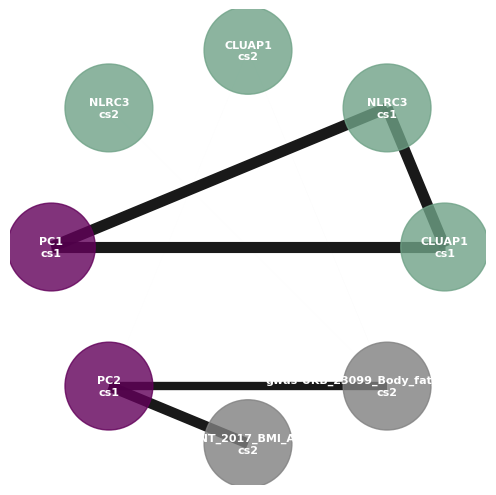

In [ ]:
# Create an undirected graph
G = nx.Graph()

# Add edges to the graph with weights
for index, row in pd.concat([cluster_pairs_qtl, cluster_gwas_pairs]).iterrows():
    G.add_edge(row['id1_short'], row['id2_short'], weight=row['PP.H4.abf'])

# Get edge weights for thickness
edge_weights = [G[u][v]['weight']*8 for u, v in G.edges()]
edge_colors = ['k' if G[u][v]['weight'] > 0.75 else 'gray' for u, v in G.edges()]
node_colors = [qtl_palette['Neither'] if 'gwas' in node else qtl_palette['pcQTL only'] if 'PC' in node else qtl_palette['eQTL only'] for node in G.nodes()]

fig, ax = plt.subplots(figsize=(5, 5)) 

# Use a rescaled circular layout to prevent nodes from running off the edge
pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color=node_colors, alpha=.8, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=.9, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='white', font_weight='bold')
ax.axis('off')  # Turn off the axis

plt.tight_layout()
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s13_a.png", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# afc information 
pcqtl_afc = load_across_tissues(config, load_pc_afc)
susie_annotated['gene_id'] = susie_annotated['cluster_id'].str.split('_')
susie_explode = susie_annotated.explode('gene_id')

# merge in afc information
susie_explode_afc = pd.merge(susie_explode, pcqtl_afc[['pid', 'sid', 'tissue_id', 'log2_aFC']], left_on=['gene_id', 'variant_id', 'tissue_id'], 
    right_on=['pid', 'sid', 'tissue_id'], how='left')

# pip-weighted afc over credible set
susie_explode_afc['pip_afc'] = susie_explode_afc['pip'] * susie_explode_afc['log2_aFC']
credible_set_grouped_afc = susie_explode_afc.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id']).agg({'pip_afc':'sum', 'pip':'sum'}).reset_index()
credible_set_grouped_afc['pip_afc_weighted'] = credible_set_grouped_afc['pip_afc']/credible_set_grouped_afc['pip']
credible_set_grouped_afc['abs_pip_afc_weighted'] = credible_set_grouped_afc['pip_afc_weighted'].abs()
credible_set_grouped_afc[credible_set_grouped_afc['phenotype_id'].str.contains(example_cluster_id)]

,phenotype_id,cs_id,tissue_id,gene_id,pip_afc,pip,pip_afc_weighted,abs_pip_afc_weighted
1533,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,Adipose_Subcutaneous,ENSG00000103351.12,1.512295,1.000000,1.512295,1.512295
1534,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,Adipose_Subcutaneous,ENSG00000167984.17,-1.266458,1.000000,-1.266458,1.266458
1535,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,Adipose_Subcutaneous,ENSG00000103351.12,0.000000,0.986032,0.000000,0.000000
1536,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,Adipose_Subcutaneous,ENSG00000167984.17,0.000000,0.986032,0.000000,0.000000
1537,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,Adipose_Subcutaneous,ENSG00000103351.12,1.512294,0.999999,1.512295,1.512295
1538,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,Adipose_Subcutaneous,ENSG00000167984.17,-1.266457,0.999999,-1.266458,1.266458
1539,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,Adipose_Subcutaneous,ENSG00000103351.12,0.000000,0.953492,0.000000,0.000000
1540,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,ENSG00000103351.12_ENSG00000167984.17_e_ENSG00...,Adipose_Subcutaneous,ENSG00000167984.17,0.000000,0.953492,0.000000,0.000000
1541,ENSG00000103351.12_ENSG00000167984.17_pc1,ENSG00000103351.12_ENSG00000167984.17_pc1_cs_1,Adipose_Subcutaneous,ENSG00000103351.12,1.512295,1.000000,1.512295,1.512295
1542,ENSG00000103351.12_ENSG00000167984.17_pc1,ENSG00000103351.12_ENSG00000167984.17_pc1_cs_1,Adipose_Subcutaneous,ENSG00000167984.17,-1.266458,1.000000,-1.266458,1.266458


/local/scratch/klawren/slrmtmp.48776383/ipykernel_59241/710893626.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  egene_cs_lead_variant_id = egene_cs.groupby('cs_id').apply(lambda x: x[x['pip'] == x['pip'].max()]['variant_id'].iloc[0]).reset_index(name='variant_id')['variant_id'].values
/local/scratch/klawren/slrmtmp.48776383/ipykernel_59241/710893626.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  egene_cs

['chr16_3539024_AC_A_b38' 'chr16_3606556_G_A_b38']
['chr16_3539024_AC_A_b38' 'chr16_3538166_T_G_b38']


/local/scratch/klawren/slrmtmp.48776383/ipykernel_59241/710893626.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  egene_cs_lead_variant_id = egene_cs.groupby('cs_id').apply(lambda x: x[x['pip'] == x['pip'].max()]['variant_id'].iloc[0]).reset_index(name='variant_id')['variant_id'].values
/local/scratch/klawren/slrmtmp.48776383/ipykernel_59241/710893626.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  egene_cs

['chr16_3539024_AC_A_b38' 'chr16_3606556_G_A_b38']
['chr16_3539024_AC_A_b38' 'chr16_3538166_T_G_b38']


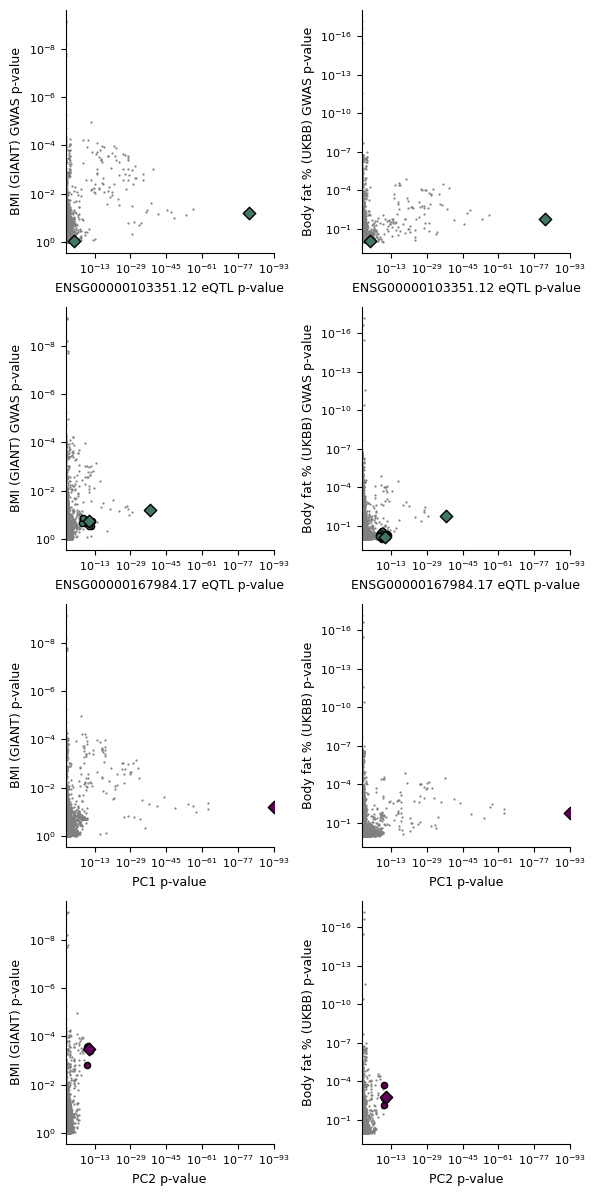

In [ ]:
num_genes = len(example_cluster_id.split('_'))
min_pval = min(nominal_e['pval_nominal'].min(), nominal_pc['pval_nominal'].min())
rounded_min_pval = 10 ** round(math.log10(min_pval))

fig, ax = plt.subplots(ncols=len(example_gwas_traits), nrows=num_genes*2, figsize=(3*len(example_gwas_traits), 6*num_genes))

for gwas_trait_idx in range(len(example_gwas_traits)):
    for i in range(num_genes):
        gene_id = example_cluster_id.split('_')[i]
        plot_egene_coloc(ax[i, gwas_trait_idx], gene_id, gene_id, nominal_e, gwas_data[gwas_trait_idx], gwas_names[gwas_trait_idx], plot_example_cs=False)

    for i in range(2):
        plot_pcgene_coloc(ax[i+num_genes, gwas_trait_idx], i+1, nominal_pc, gwas_data[gwas_trait_idx], gwas_names[gwas_trait_idx], plot_example_cs=False)

for axes in ax.flatten():
    axes.set_xlim(1, rounded_min_pval)

plt.tight_layout()
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s13_c.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()

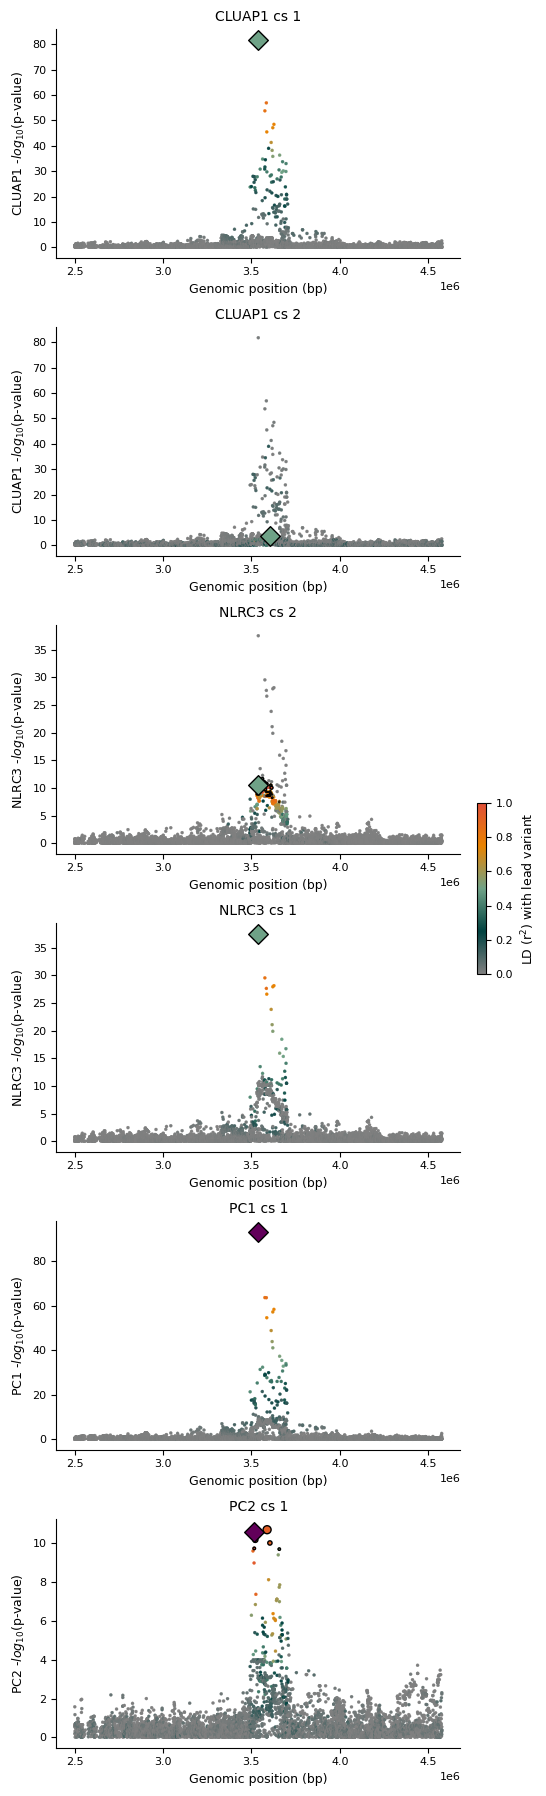

In [ ]:
example_cluster_cs = susie_annotated[susie_annotated['phenotype_id'].str.contains(example_cluster_id)]

fig, ax = plt.subplots(figsize=(5, 3*example_cluster_cs['cs_id'].nunique()), nrows=example_cluster_cs['cs_id'].nunique(), ncols=1)

# make a locuszoom for each credible set
for i, cs_id in enumerate(example_cluster_cs['cs_id'].unique()):
    if '_e_' in cs_id:
        cs_nominal = nominal_e[nominal_e['phenotype_id'] == cs_id.split('_cs')[0]].copy()
        lead_var_color = qtl_palette['eQTL only']
        pheno_label = get_gene_name(cs_id.split('_e_')[-1].split('_cs')[0], config) + '_cs' + cs_id.split('_cs')[-1]

    else:
        cs_nominal = nominal_pc[nominal_pc['phenotype_id'] == cs_id.split('_cs')[0]].copy()
        lead_var_color = qtl_palette['pcQTL only']
        pheno_label = 'PC' + cs_id.split('_pc')[-1]

    cs_susie = susie_annotated[susie_annotated['cs_id'] == cs_id]
    cs_variant_ids= cs_susie['variant_id'].unique()
    lead_variant_id = cs_susie[cs_susie['pip'] == cs_susie['pip'].max()]['variant_id'].values[0]

    cs_nominal['in_cs'] = cs_nominal['variant_id'].isin(cs_variant_ids)
    cs_nominal['pos'] = cs_nominal['variant_id'].str.split('_').str[1].astype(int)

    # Compute LD with lead variant if available
    if lead_variant_id is not None and lead_variant_id in ld.index:
        ld_with_lead = ld.loc[lead_variant_id]
        cs_nominal = cs_nominal.set_index('variant_id')
        cs_nominal['ld_with_lead'] = ld_with_lead[cs_nominal.index].values ** 2
        cs_nominal = cs_nominal.reset_index()


    # Plot
    sns.scatterplot(
        data=cs_nominal, 
        x='pos', 
        y=-np.log10(cs_nominal['pval_nominal']), 
        hue='ld_with_lead', 
        palette=ld_palette, 
        edgecolor=None, 
        legend=False,
        s=5,
        alpha=1, 
        ax=ax[i], 
        hue_norm=ld_norm

    )
    if len(cs_susie) > 1:
        # Highlight credible set variants
        sns.scatterplot(
            data=cs_nominal[cs_nominal['in_cs']],
            x='pos',
            y=-np.log10(cs_nominal[cs_nominal['in_cs']]['pval_nominal']),
            hue='ld_with_lead', 
            palette=ld_palette, 
            marker='o',
            s=cs_susie['pip']*100,
            edgecolor='k',
            linewidth=1,
            alpha=1,
            ax=ax[i],
            legend=False, 
            hue_norm=ld_norm
        )  

    # Highlight lead variant
    sns.scatterplot(
        data=cs_nominal[cs_nominal['variant_id'] == lead_variant_id],
        x='pos',
        y=-np.log10(cs_nominal[cs_nominal['variant_id'] == lead_variant_id]['pval_nominal']),
        marker='D',
        color=lead_var_color,
        s=100,
        edgecolor='k',
        linewidth=1,
        alpha=1,
        ax=ax[i],
        legend=False
    )   
    ax[i].set_ylabel('{} '.format(pheno_label.split('_')[0]) + r'-$log_{10}$(p-value)')
    ax[i].set_xlabel('Genomic position (bp)')
    ax[i].set_title(pheno_label.replace('_', ' '))
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)


plt.tight_layout()

# Add the colorbar to the right of the last axis
sm = mpl.cm.ScalarMappable(cmap=ld_palette, norm=ld_norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('LD (r$^2$) with lead variant')
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s13_b.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()  
    


In [ ]:
# load in expression
expression = load_cluster_expression(config, 'Adipose_Subcutaneous')
cluster_expresison = expression[expression['gene_id'].str.contains(example_cluster_id)]
sample_columns = cluster_expresison.columns[cluster_expresison.columns.str.contains('GTEX')]
cluster_expresison['egene_id'] = cluster_expresison['gene_id'].str.split('_e_').str[-1]
cluster_expresison['cluster_id'] = cluster_expresison['gene_id'].str.split('_e_').str[0]

cluster_expression_pivot = cluster_expresison[sample_columns].T
cluster_expression_pivot.columns = cluster_expresison['egene_id']

pcs = load_pc(config, 'Adipose_Subcutaneous')
cluster_pcs = pcs[pcs['gene_id'].str.contains(example_cluster_id)]
cluster_pcs_pivot = cluster_pcs[sample_columns].T
cluster_pcs_pivot.columns = ['pc1', 'pc2']

# get the genotypes
# with something like "bcftools view -r chr16:3516362 "$vcf_file" | tail -n 2 > chr16.3516362.genotype.txt"
genotypes = pd.read_csv('/home/klawren/oak/pcqtls/data/processed/genotypes/chr16.3516362.genotype.txt', sep='\t')
cluster_expression_pivot['genotype'] = genotypes[sample_columns].T
cluster_expression_pivot['genotype_collapsed'] = cluster_expression_pivot['genotype'].str.count('1')

# get the correlations
correlation_results = cluster_expression_pivot.groupby('genotype_collapsed').apply(
    lambda group: spearmanr(group['ENSG00000103351.12'], group['ENSG00000167984.17']))

/local/scratch/klawren/slrmtmp.48776383/ipykernel_59241/757889769.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_expresison['egene_id'] = cluster_expresison['gene_id'].str.split('_e_').str[-1]
/local/scratch/klawren/slrmtmp.48776383/ipykernel_59241/757889769.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_expresison['cluster_id'] = cluster_expresison['gene_id'].str.split('_e_').str[0]
/local/scratch/klawren/slrmtmp.48776383/ipykernel_59241/757889769.py:23: FutureWarning: DataFrameGr

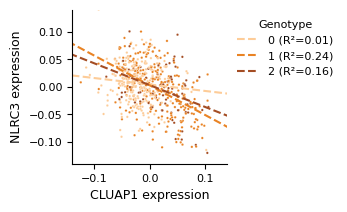

In [ ]:
# Plotting CLUAP1 vs NLRC3 expression colored by genotype, with regression lines per genotype group
# Legend now shows R² (coefficient of determination) for each genotype group

fig, ax = plt.subplots(figsize=(2, 2))
genotype_palette = {0: '#FDCC98', 1: '#E98324', 2: '#A44D24'}

sns.scatterplot(
    data=cluster_expression_pivot,
    x='ENSG00000103351.12',
    y='ENSG00000167984.17',
    hue='genotype_collapsed',
    s=3,
    palette=genotype_palette,
    legend=False,
    ax=ax
)

from sklearn.linear_model import LinearRegression

# Store R² values for legend
r2_dict = {}

for genotype in [0, 1, 2]:
    subset = cluster_expression_pivot[cluster_expression_pivot['genotype_collapsed'] == genotype]
    x = subset['ENSG00000103351.12'].values.reshape(-1, 1)
    y = subset['ENSG00000167984.17'].values
    if len(x) > 1:  # Only fit if there are at least 2 points
        model = LinearRegression().fit(x, y)
        x_vals = np.linspace(-.2, .2, 100).reshape(-1, 1)
        y_vals = model.predict(x_vals)
        r2 = model.score(x, y)
        r2_dict[genotype] = r2
        ax.plot(
            x_vals,
            y_vals,
            label=f'{genotype} (R²={r2:.2f})',
            color=genotype_palette[genotype],
            ls='--'
        )
    else:
        r2_dict[genotype] = float('nan')

# Add legend with R² values
ax.legend(title='Genotype', loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

ax.set_xlim(-.14, .14)
ax.set_ylim(-.14, .14)
ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('CLUAP1 expression')
ax.set_ylabel('NLRC3 expression')


plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s13_d.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Extract the correlation coefficients and sample sizes
r1 = correlation_results.loc[0][0]  # Correlation for the first genotype
r2 = correlation_results.loc[2][0]  # Correlation for the second genotype
n1 = cluster_expression_pivot[cluster_expression_pivot['genotype_collapsed'] == correlation_results.index[0]].shape[0]
n2 = cluster_expression_pivot[cluster_expression_pivot['genotype_collapsed'] == correlation_results.index[1]].shape[0]

# Fisher's z-transformation
def fisher_z(r):
    return 0.5 * np.log((1 + r) / (1 - r))

z1 = fisher_z(r1)
z2 = fisher_z(r2)

# Standard error for the difference between two correlations
SE = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))

# Calculate the z-score for the difference
z_score = (z1 - z2) / SE

# Calculate the p-value
p_value = 2 * (1 - norm.cdf(abs(z_score)))  # Two-tailed test

# Output results
print(f"Correlation for group 1: {r1}, Sample size: {n1}")
print(f"Correlation for group 2: {r2}, Sample size: {n2}")
print(f"Z-score: {z_score}, P-value: {p_value}")

# Check if each correlation is significantly different from zero
p_value_r1 = 2 * (1 - norm.cdf(abs(fisher_z(r1) / np.sqrt(1/(n1 - 2)))))
p_value_r2 = 2 * (1 - norm.cdf(abs(fisher_z(r2) / np.sqrt(1/(n2 - 2)))))

print(f"P-value for correlation in group 1: {p_value_r1}")
print(f"P-value for correlation in group 2: {p_value_r2}")

Correlation for group 1: -0.06344584607285318, Sample size: 261
Correlation for group 2: -0.36190391886594414, Sample size: 242
Z-score: 3.5147167563967403, P-value: 0.00044022324807513336
P-value for correlation in group 1: 0.30657381570671793
P-value for correlation in group 2: 4.289993027484229e-09
